# K-Means

## Pipline 


Data gốc (46D): đã sclae+encodeing từ bước trước
        ↓
[Clustering]
- KMeans thường

[Giảm chiều]
PCA (với dữ liệu liên tục) sau đó ghép với biến rời rạc  / UMAP (≈15D)
        ↓
[Clustering]
- Kmmean thường + giảm chieuf 
- KMeans thường+ giảm chiều + thay đổi khoảng cách phù hợ với bộ dữ liệu 
- KMeans Constrained

-> áp dụng pca, umap cho cả 2 phương pháp, dùng pca thì visualization bằng pca và ngược lại 

ở các phương pháp đều: 
Đánh giá:
- Silhouette
- Davies-Bouldin
- Calinski-Harabasz
- Phân bố kích thước cụm
        ↓
Phân tích quan hệ giữa:
- đặc trưng đầu vào
- charges/output
trong từng cụm

visualizate cho hết vào 1-3 cái khung tùy kích thước,đảm bảo có biểu đồ (phân phối kích thước cụm, phân phối charges theo từng cụm,  heatmap theo từng cluster)
        ↓
[Chuyển sang Classification]
Cách 1:
Dùng nhãn từ KMeans Constrained

Cách 2:
Tạo score từ clustering
(distance / charges / risk score)
→ pd.qcut chia 3 lớp gần đều
        ↓
[Classification]
- Gaussian Naive Bayes
- Logistic Regression / Random Forest
        ↓
So sánh:
- dữ liệu gốc
- dữ liệu giảm chiều

## 1. Import thư viện và cấu hình chung

In [16]:

# ============================================================
# THƯ VIỆN
# ============================================================

# Cơ bản
import numpy as np
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import umap

# Clustering
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# Clustering metrics
from sklearn.metrics import (
    silhouette_score, silhouette_samples, 
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Classification
from sklearn.naive_bayes import GaussianNB

# Classification metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    fowlkes_mallows_score,
)

# Display
from IPython.display import display, Markdown

# Màu sắc cho các cụm
COLORS = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6',
          '#1ABC9C', '#E67E22', '#34495E', '#E91E63', '#00BCD4']


RANDOM_STATE = 42
TARGET_COL = "charges"
DATA_PATH = "data/support2_final.csv"



## 2. Đọc dữ liệu và tách input/output

In [14]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
# df.head()

# print(df.dtypes)
# print("\n---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values | sample: {df[col].unique()[:5]}")
    
X = df.drop(columns = [TARGET_COL]).copy()
y = df[TARGET_COL].copy()

feature_names = X.columns.tolist()


Shape: (8933, 47)
Missing values: 0
age: 85 unique values | sample: [ 0.01931442 -0.17324779 -0.62255962 -1.32862106  1.11050029]
sex: 2 unique values | sample: [0 1]
num.co: 10 unique values | sample: [-1.39331441  0.09256604 -0.65037418  0.83550627  1.5784465 ]
edu: 31 unique values | sample: [-2.38759379e-01  8.18340875e-02  5.69488397e-16  7.23021020e-01
  1.36420795e+00]
income: 4 unique values | sample: [1 0 2 3]
scoma: 11 unique values | sample: [-0.48688655  1.30736923  0.5733555   1.75593317  1.02191944]
charges: 8501 unique values | sample: [ 9.18152929 10.44862764 10.62364174  8.03138533 10.82233501]
avtisst: 353 unique values | sample: [-1.18087715  0.4915256  -0.72476731 -0.29399771 -1.33291377]
sps: 600 unique values | sample: [ 0.93244586  2.11293293 -0.39462956 -0.44638497 -0.03677092]
aps: 124 unique values | sample: [-0.83553434  1.44870793  0.57150884 -0.92308466 -0.13666877]
hday: 84 unique values | sample: [-0.3709122  -0.15054316 -0.04035864 15.82621201  0.9513020

### Dữ liệu đầu vào 

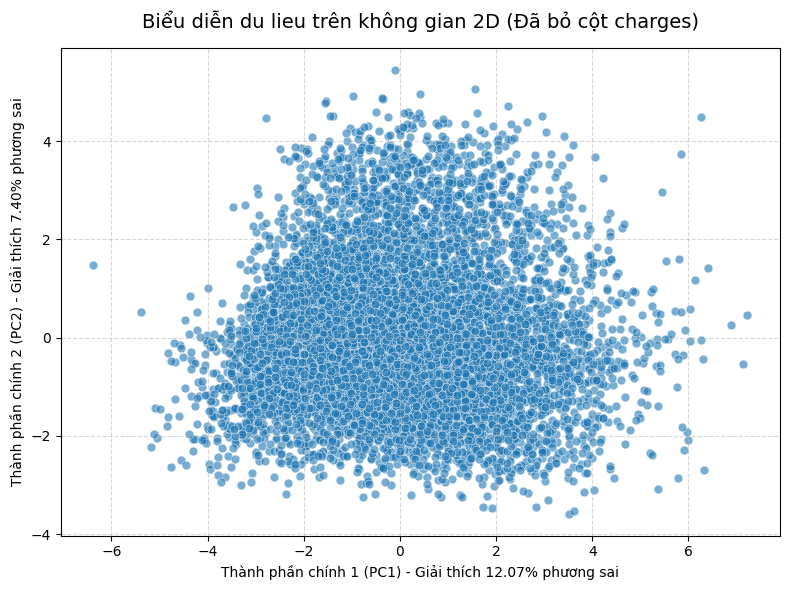

In [3]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)
plt.figure(figsize = (8,6))

sns.scatterplot(
    x = X_pca[:, 0], 
    y = X_pca[:, 1],
    palette = 'viridis',
    alpha = 0.6,
    s=40
)

plt.title(f'Biểu diễn du lieu trên không gian 2D (Đã bỏ cột charges)', fontsize=14, pad=15)
plt.xlabel(f'Thành phần chính 1 (PC1) - Giải thích {pca.explained_variance_ratio_[0]:.2%} phương sai')
plt.ylabel(f'Thành phần chính 2 (PC2) - Giải thích {pca.explained_variance_ratio_[1]:.2%} phương sai')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()



## 3. Tách biến liên tục và biến rời rạc/binary

In [4]:
def infer_discrete_continuous_cols(X_df, max_unique_for_discrete=5):
    discrete_cols = []
    continuous_cols = []

    for col in X_df.columns:
        values = X_df[col].dropna().unique()
        unique_count = len(values)
        is_binary = set(np.round(values, 8)).issubset({0, 1})

        if is_binary or unique_count <= max_unique_for_discrete:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)

    return continuous_cols, discrete_cols

continuous_cols, discrete_cols = infer_discrete_continuous_cols(X)

X_cont = X[continuous_cols].copy()
X_disc = X[discrete_cols].copy()

assert X_cont.shape[1] + X_disc.shape[1] == X.shape[1]
print(f"Biến liên tục : {X_cont.shape[1]} cột")
print(f"Biến rời rạc  : {X_disc.shape[1]} cột")
print(f"Tổng          : {X.shape[1]} cột")

Biến liên tục : 25 cột
Biến rời rạc  : 21 cột
Tổng          : 46 cột


## 4. Hàm chung

In [21]:
# Đánh giá mẫu dữ liệu đầu vào: 
def evaluate_internal(X, labels, model_name='KMeans'):
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    print(f"\n{'='*50}")
    print(f"  Internal Metrics — {model_name}")
    print(f"{'='*50}")
    print(f"  Silhouette Score    : {sil:+.4f}  ")
    print(f"  Davies-Bouldin Index: {db:.4f}   ")
    print(f"  Calinski-Harabasz   : {ch:.1f} ")
    print(f"{'='*50}\n")

    return {'model': model_name, 'silhouette': sil,
            'davies_bouldin': db, 'calinski_harabasz': ch}

# Đánh giá quan hệ giữa các dầu ra
def evaluate_external(df, labels, target_col='charges', n_bins=3, model_name='KMeans'):
    df = df.copy()
    df['_cluster'] = labels

    # Rời rạc hóa charges thành n_bins mức đều nhau (theo quantile)
    bin_labels = ['Thấp', 'Trung bình', 'Cao'][:n_bins]
    df['_target_bin'] = pd.qcut(df[target_col], q=n_bins, labels=bin_labels)

    ari = adjusted_rand_score(df['_target_bin'], labels)
    fmi = fowlkes_mallows_score(df['_target_bin'], labels)

    # Trung bình charges theo từng cụm
    mean_charges = df.groupby('_cluster')[target_col].mean().sort_values()

    print(f"\n{'='*50}")
    print(f"  External Metrics — {model_name} vs '{target_col}'")
    print(f"{'='*50}")
    print(f"  ARI (Adjusted Rand Index)  : {ari:+.4f}  (>0 = tốt hơn ngẫu nhiên)")
    print(f"  FMI (Fowlkes-Mallows Index): {fmi:.4f}   (0→1, cao hơn tốt hơn)")
    print(f"\n  Trung bình '{target_col}' theo cụm:")
    for cid, val in mean_charges.items():
        print(f"    Cluster {cid}: {val:.4f}")
    print(f"\n  Crosstab cụm × mức {target_col}:")
    print(pd.crosstab(df['_cluster'], df['_target_bin'], margins=True))
    print(f"{'='*50}\n")

    return {'model': model_name, 'ari': ari, 'fmi': fmi,
            'mean_target_per_cluster': mean_charges.to_dict()}


# pca_plot 
def plot_clusters_pca(X, labels, km_model=None,
                      title='K-Means', ax=None):
    
    k = len(np.unique(labels))
    pca = PCA(n_components=2, random_state=42)
    X2  = pca.fit_transform(X)
    var = pca.explained_variance_ratio_

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')

    if km_model is not None and hasattr(km_model, 'cluster_centers_'):
        centroids_2d = pca.transform(km_model.cluster_centers_)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=200, zorder=5, label='Centroid')

    ax.set_title(f'{title} – PCA 2D\n'
                 f'(PC1={var[0]:.1%}, PC2={var[1]:.1%})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)

    if standalone:
        plt.tight_layout()
        plt.show()

# umap_plot 
def plot_clusters_umap(X, labels, km_model=None,
                       title='K-Means', ax=None):
    
    k = len(np.unique(labels))
    reducer = umap.UMAP(n_components=2, random_state=42)
    X2 = reducer.fit_transform(X)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')

    if km_model is not None and hasattr(km_model, 'cluster_centers_'):
        centroids_2d = reducer.transform(km_model.cluster_centers_)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=200, zorder=5, label='Centroid')

    ax.set_title(f'{title} – UMAP 2D', fontweight='bold', fontsize=10)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)

    if standalone:
        plt.tight_layout()
        plt.show()


# Phân phối kích thước cụm
def plot_cluster_distribution(labels, title='KMeans', ax=None):
    """Pie chart thể hiện tỉ lệ mẫu trong từng cụm."""
    k = len(np.unique(labels))
    sizes = [np.sum(labels == c) for c in range(k)]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.pie(sizes,
           labels=[f'Cluster {c}\n({s:,})' for c, s in enumerate(sizes)],
           colors=COLORS[:k],
           autopct='%1.1f%%',
           startangle=140,
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title(f'Phân phối kích thước cụm — {title}', fontweight='bold')

    if standalone:
        plt.tight_layout()
        plt.show()


# HEATMAP ĐẶC TRƯNG THEO CỤM
def plot_feature_heatmap(df, labels, feature_names,
                         top_n=20, title='KMeans', ax=None):
    k = len(np.unique(labels))
    df = df.copy()
    df['_cluster'] = labels

    feats = [f for f in feature_names if f in df.columns]
    cluster_means = np.array([
        df[df['_cluster'] == c][feats].mean().values for c in range(k)
    ])
    feat_std = cluster_means.std(axis=0)
    top_idx  = np.argsort(feat_std)[::-1][:top_n]
    top_feats = [feats[i] for i in top_idx]
    data = cluster_means[:, top_idx]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(14, top_n * 0.7), 3 + k))

    im = ax.imshow(data, aspect='auto', cmap='RdYlGn',
                   vmin=-1.5, vmax=1.5)
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(k))
    ax.set_yticklabels([f'Cluster {c} (n={np.sum(labels==c):,})'
                        for c in range(k)], fontsize=10)
    ax.set_title(f'Heatmap — Top {top_n} đặc trưng phân biệt — {title}',
                 fontweight='bold')

    for i in range(k):
        for j in range(len(top_feats)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', fontsize=6, color='black')

    if standalone:
        plt.colorbar(im, ax=ax, label='Giá trị chuẩn hóa')
        plt.tight_layout()
        plt.show()
    else:
        plt.colorbar(im, ax=ax, label='Giá trị chuẩn hóa')



def full_cluster_report(
    X,
    df,
    labels,
    km_model=None,
    feature_names=None,
    df_for_heatmap=None,
    target_col='charges',
    model_name='KMeans',
    use_umap=False,
    top_n_features=20
):
    """
    X              : dữ liệu dùng để phân cụm / tính metric
    df             : DataFrame gốc có chứa target_col, ví dụ charges
    labels         : nhãn cụm
    km_model       : mô hình phân cụm
    feature_names  : tên feature gốc dùng để vẽ heatmap
    df_for_heatmap : DataFrame feature gốc sau tiền xử lý, thường là X gốc
    target_col     : biến đầu ra để đánh giá, ví dụ charges
    model_name     : tên mô hình
    use_umap       : True nếu muốn vẽ scatter bằng UMAP
    top_n_features : số feature hiển thị trên heatmap
    """

    # Nếu không truyền df_for_heatmap thì dùng df
    if df_for_heatmap is None:
        df_for_heatmap = df.copy()

    # Nếu chưa truyền feature_names thì lấy từ df_for_heatmap
    if feature_names is None:
        feature_names = df_for_heatmap.columns.tolist()

    # Nếu feature_names là Index thì đổi sang list
    feature_names = list(feature_names)

    # Đánh giá metric
    internal = evaluate_internal(X, labels, model_name)
    external = evaluate_external(df, labels, target_col, model_name=model_name)

    # Tạo figure 2x3
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'Cluster Report — {model_name}', fontsize=15, fontweight='bold')

    # ========================================================
    # [0,0] Scatter PCA hoặc UMAP
    # ========================================================
    if use_umap:
        plot_clusters_umap(X, labels, km_model, title=model_name, ax=axes[0, 0])
    else:
        plot_clusters_pca(X, labels, km_model, title=model_name, ax=axes[0, 0])

    # ========================================================
    # [0,1] Phân phối kích thước cụm
    # ========================================================
    plot_cluster_distribution(labels, model_name, ax=axes[0, 1])

    # ========================================================
    # [0,2] Mean charges theo cụm
    # ========================================================
    df_tmp = df.copy()
    df_tmp['_cluster'] = labels

    mean_charges = df_tmp.groupby('_cluster')[target_col].mean()
    x_pos = np.arange(len(mean_charges))

    axes[0, 2].bar(
        x_pos,
        mean_charges.values,
        color=[COLORS[c] for c in mean_charges.index],
        edgecolor='white',
        linewidth=1.5
    )

    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels([f'Cluster {c}' for c in mean_charges.index])

    for i, (c, val) in enumerate(zip(mean_charges.index, mean_charges.values)):
        axes[0, 2].text(
            i,
            val + mean_charges.max() * 0.01,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    axes[0, 2].set_title(f'Mean {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[0, 2].set_ylabel(f'Mean {target_col}')
    axes[0, 2].grid(True, axis='y', alpha=0.3)

    # ========================================================
    # [1,0] Boxplot charges theo cụm
    # ========================================================
    clusters = sorted(np.unique(labels))

    axes[1, 0].boxplot(
        [df_tmp[df_tmp['_cluster'] == c][target_col].values for c in clusters],
        labels=[f'Cluster {c}' for c in clusters],
        patch_artist=True,
        boxprops=dict(facecolor='#f0f0f0'),
        medianprops=dict(color='red', linewidth=2)
    )

    for c in clusters:
        vals = df_tmp[df_tmp['_cluster'] == c][target_col].values
        axes[1, 0].scatter(
            np.full(len(vals), c + 1) + np.random.uniform(-0.15, 0.15, len(vals)),
            vals,
            alpha=0.15,
            s=6,
            color=COLORS[c]
        )

    axes[1, 0].set_title(f'Phân phối {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[1, 0].set_xlabel('Cluster')
    axes[1, 0].set_ylabel(target_col)
    axes[1, 0].grid(True, axis='y', alpha=0.3)

    # ========================================================
    # [1,1] Heatmap đặc trưng theo cụm
    # ========================================================
    plot_feature_heatmap(
        df=df_for_heatmap,
        labels=labels,
        feature_names=feature_names,
        top_n=top_n_features,
        title=model_name,
        ax=axes[1, 1]
    )

    # ========================================================
    # [1,2] Bảng metric tóm tắt
    # ========================================================
    axes[1, 2].axis('off')

    metric_text = (
        f"Internal Metrics\n"
        f"Silhouette: {internal['silhouette']:.4f}\n"
        f"Davies-Bouldin: {internal['davies_bouldin']:.4f}\n"
        f"Calinski-Harabasz: {internal['calinski_harabasz']:.1f}\n\n"
        f"External Metrics vs {target_col}\n"
        f"ARI: {external['ari']:.4f}\n"
        f"FMI: {external['fmi']:.4f}"
    )

    axes[1, 2].text(
        0.05,
        0.75,
        metric_text,
        fontsize=13,
        va='top',
        family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#cccccc')
    )

    axes[1, 2].set_title('Tóm tắt chỉ số đánh giá', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return {
        **internal,
        **{f'ext_{k}': v for k, v in external.items()}
    }


## 5. K_Means trên dữ liệu chưa giảm chiều

In [10]:
results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    results.append({
        'k': k,
        'Silhouette': round(silhouette_score(X, labels), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X, labels), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X, labels), 1),
    })

df_results = pd.DataFrame(results).set_index('k')
print("=== KMeans (Không giảm chiều)")
display(df_results)

=== KMeans (Không giảm chiều)


,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,
2,0.0969,3.2833,776.2
3,0.0873,2.9884,622.2
4,0.0834,2.8777,536.8
5,0.0446,2.8651,487.4
6,0.0535,2.8661,444.2
7,0.0468,2.9053,411.8


## 6. Giảm chiều

In [11]:
# PCA: chỉ áp dụng cho biến liên tục, ghép lại biến rời rạc
pca = PCA(n_components=0.70, random_state=42)
X_cont_pca = pca.fit_transform(X_cont)
X_pca_reduced = np.hstack([X_cont_pca, X_disc.values])
pca_col_names = ([f'PC{i+1}' for i in range(X_cont_pca.shape[1])] + list(X_disc.columns))
X_pca_reduced = pd.DataFrame(X_pca_reduced, columns=pca_col_names, index=X.index)
print(f"PCA: {X_cont.shape[1]}D → {X_cont_pca.shape[1]}D + {X_disc.shape[1]}D rời rạc "
      f"= {X_pca_reduced.shape[1]}D | variance: {pca.explained_variance_ratio_.sum():.2%}")

# UMAP: áp dụng toàn bộ
reducer = umap.UMAP(n_components=15, random_state=42)
X_umap_arr = reducer.fit_transform(X)
umap_col_names = [f'UMAP{i+1}' for i in range(X_umap_arr.shape[1])]
X_umap_reduced = pd.DataFrame(X_umap_arr, columns=umap_col_names, index=X.index)
print(f"UMAP: {X.shape[1]}D → {X_umap_reduced.shape[1]}D")

PCA: 25D → 13D + 21D rời rạc = 34D | variance: 71.79%
UMAP: 46D → 15D


## 7. K-Means giảm chiều + các phương pháp khác

### K-Means + Giảm chiều

In [17]:
# ============================================================
# HÀM CHẠY K-MEANS + GIẢM CHIỀU
# ============================================================

def run_kmeans_reduced(
    X_reduced,
    df,
    X_original,
    k=3,
    dim_name="PCA",
    target_col="charges",
    random_state=42
):

    X_array = (
        X_reduced.values
        if hasattr(X_reduced, "values")
        else np.asarray(X_reduced)
    )

    feature_names = X_original.columns.tolist()

    kmeans_model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=random_state
    )

    labels = kmeans_model.fit_predict(X_array)

    metrics = full_cluster_report(
        X=X_array,
        df=df,
        labels=labels,
        km_model=kmeans_model,
        feature_names=feature_names,
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f"KMeans + {dim_name}",
        use_umap=(dim_name.upper() == "UMAP")
    )

    metrics.update({
        "method": "KMeans",
        "dim_reduction": dim_name,
        "k": k
    })

    return labels, metrics, kmeans_model

### K-Means + Giảm chiều + Gower

In [ ]:
def fit_kmedoids_gower(X_cluster, k=3, categorical_cols=None,
                       model_name="K-Medoids + Gower", random_state=42):
    """
    K-Medoids với Gower distance.
    Trả thêm D_gower và X_embed (MDS) để truyền vào full_cluster_report.
    """
    print(f"[{model_name}] Đang tính Gower distance matrix...")
    D_gower = gower_distance_matrix(X_cluster, categorical_cols=categorical_cols)

    labels, medoid_idx = kmedoids_precomputed(D_gower, k=k, random_state=random_state)

    sil_gower = silhouette_score(D_gower, labels, metric="precomputed")
    print(f"[{model_name}] Silhouette (Gower precomputed): {sil_gower:.4f}")
    print(f"[{model_name}] Medoid indices: {medoid_idx}")
    print(f"[{model_name}] Phân phối cụm:\n{pd.Series(labels).value_counts().sort_index()}")

    # MDS embedding để visualize và truyền vào full_cluster_report
    X_embed = classical_mds(D_gower, n_components=5)
    model   = DummyMedoidModel(labels=labels, X_embed=X_embed)

    return labels, model, D_gower, X_embed, sil_gower

## K-means trên dữ liệu đã giảm chiều 

In [12]:

# Khởi tạo mô hình K-Means (ở đây tao đang để ví dụ n_clusters=3, mày tự chỉnh theo khuỷu tay/Silhouette nhé)
kmeans_model = KMeans(n_clusters=3, random_state=42)

# Fit và dự đoán nhãn cụm
kmeans_labels = kmeans_model.fit_predict(X_for_kmeans)

# Gọi hàm đánh giá (mày nhớ đảm bảo hàm full_cluster_report đã được định nghĩa và chạy trước đó)
kmeans_metrics = full_cluster_report(
    X=X_for_kmeans.values, 
    df=df, 
    labels=kmeans_labels, 
    km_model=kmeans_model, 
    feature_names=X_for_kmeans.columns, 
    target_col='charges',
    model_name='KMeans (Đã giảm chiều)',
    use_umap=USE_UMAP  # Lấy luôn biến USE_UMAP mày vừa khai báo ở trên để hàm tự biết đường vẽ
)

NameError: name 'X_for_kmeans' is not defined

## K-means trên dữ liệu đã giảm chiều và thay đổi khoảng cách Grower 

In [82]:
# ============================================================
# K-MEDOIDS + GOWER DISTANCE TỰ VIẾT
# Không dùng thư viện gower, không dùng sklearn_extra
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score


# ------------------------------------------------------------
# 1. Hàm tính Gower Distance Matrix
# ------------------------------------------------------------

def gower_distance_matrix(X, categorical_cols=None, chunk_size=500):
    """
    Tính ma trận Gower distance cho dữ liệu mixed:
    - Numeric/continuous: |xi - xj| / range
    - Categorical/binary: 0 nếu giống, 1 nếu khác
    
    Parameters
    ----------
    X : pd.DataFrame hoặc np.ndarray
    categorical_cols : list tên cột hoặc list index cột categorical/binary
    chunk_size : int, dùng để tránh ngốn RAM quá mạnh
    
    Returns
    -------
    D : np.ndarray shape (n_samples, n_samples)
        Ma trận khoảng cách Gower
    """
    
    # Đưa về DataFrame để xử lý tên cột dễ hơn
    if isinstance(X, np.ndarray):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()
    
    n, p = X_df.shape
    
    # Nếu không truyền categorical_cols thì mặc định không có cột categorical
    if categorical_cols is None:
        categorical_cols = []
    
    # Nếu categorical_cols là tên cột
    if len(categorical_cols) > 0 and isinstance(categorical_cols[0], str):
        categorical_idx = [X_df.columns.get_loc(c) for c in categorical_cols if c in X_df.columns]
    else:
        categorical_idx = list(categorical_cols)
    
    categorical_idx = set(categorical_idx)
    numeric_idx = [i for i in range(p) if i not in categorical_idx]
    categorical_idx = list(categorical_idx)
    
    X_values = X_df.values
    
    # Tách numeric và categorical
    X_num = X_values[:, numeric_idx].astype(float) if len(numeric_idx) > 0 else None
    X_cat = X_values[:, categorical_idx] if len(categorical_idx) > 0 else None
    
    # Range cho numeric
    if X_num is not None:
        num_range = np.nanmax(X_num, axis=0) - np.nanmin(X_num, axis=0)
        num_range[num_range == 0] = 1  # tránh chia cho 0
        X_num_scaled = X_num / num_range
    else:
        X_num_scaled = None
    
    D = np.zeros((n, n), dtype=np.float32)
    
    n_num = len(numeric_idx)
    n_cat = len(categorical_idx)
    n_features = n_num + n_cat
    
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        
        dist_chunk = np.zeros((end - start, n), dtype=np.float32)
        
        # Numeric distance
        if n_num > 0:
            for j in range(n_num):
                diff = np.abs(X_num_scaled[start:end, j][:, None] - X_num_scaled[:, j][None, :])
                dist_chunk += diff.astype(np.float32)
        
        # Categorical / binary distance
        if n_cat > 0:
            for j in range(n_cat):
                diff = (X_cat[start:end, j][:, None] != X_cat[:, j][None, :]).astype(np.float32)
                dist_chunk += diff
        
        dist_chunk /= n_features
        D[start:end, :] = dist_chunk
    
    # Đảm bảo đối xứng và đường chéo = 0
    D = (D + D.T) / 2
    np.fill_diagonal(D, 0)
    
    return D


# ------------------------------------------------------------
# 2. Hàm K-Medoids dùng ma trận khoảng cách bất kỳ
# ------------------------------------------------------------

def kmedoids_precomputed(D, k=3, max_iter=100, random_state=42):
    """
    K-Medoids tự viết dùng ma trận khoảng cách precomputed.
    
    Parameters
    ----------
    D : np.ndarray shape (n_samples, n_samples)
        Ma trận khoảng cách
    k : int
        Số cụm
    max_iter : int
        Số vòng lặp tối đa
    
    Returns
    -------
    labels : np.ndarray
        Nhãn cụm
    medoid_indices : np.ndarray
        Index của các medoid
    """
    
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    
    # Khởi tạo medoid ngẫu nhiên
    medoid_indices = rng.choice(n, size=k, replace=False)
    
    for it in range(max_iter):
        # Assign: mỗi điểm vào medoid gần nhất
        distances_to_medoids = D[:, medoid_indices]
        labels = np.argmin(distances_to_medoids, axis=1)
        
        new_medoids = medoid_indices.copy()
        
        # Update: trong mỗi cụm, chọn điểm có tổng khoảng cách nhỏ nhất
        for c in range(k):
            cluster_idx = np.where(labels == c)[0]
            
            if len(cluster_idx) == 0:
                # Nếu cụm rỗng, chọn lại ngẫu nhiên
                new_medoids[c] = rng.choice(n)
                continue
            
            intra_D = D[np.ix_(cluster_idx, cluster_idx)]
            total_dist = intra_D.sum(axis=1)
            best_idx = cluster_idx[np.argmin(total_dist)]
            new_medoids[c] = best_idx
        
        # Nếu medoid không đổi thì dừng
        if np.array_equal(np.sort(new_medoids), np.sort(medoid_indices)):
            print(f"K-Medoids hội tụ sau {it + 1} vòng lặp.")
            break
        
        medoid_indices = new_medoids
    
    # Gán nhãn lần cuối
    labels = np.argmin(D[:, medoid_indices], axis=1)
    
    return labels, medoid_indices


# ------------------------------------------------------------
# 3. Classical MDS tự viết để tạo embedding từ Gower distance
# ------------------------------------------------------------

def classical_mds(D, n_components=5):
    """
    Classical MDS tự viết.
    Chuyển ma trận khoảng cách D thành tọa độ Euclidean.
    
    Mục đích:
    - Cho phép dùng full_cluster_report()
    - Vì full_cluster_report cần X dạng tọa độ, không nhận distance matrix
    """
    
    D = np.asarray(D, dtype=np.float64)
    n = D.shape[0]
    
    # Double centering
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(B)
    
    # Sắp xếp eigenvalue giảm dần
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    # Chỉ lấy eigenvalue dương
    positive = eigvals > 0
    eigvals = eigvals[positive][:n_components]
    eigvecs = eigvecs[:, positive][:, :n_components]
    
    X_embed = eigvecs * np.sqrt(eigvals)
    
    return X_embed


# ------------------------------------------------------------
# 4. Dummy model để truyền vào full_cluster_report
# ------------------------------------------------------------

class DummyMedoidModel:
    """
    Model giả để dùng với full_cluster_report().
    full_cluster_report cần object có:
    - n_clusters
    - cluster_centers_
    
    Với K-Medoids, ta dùng tâm cụm trong không gian embedding.
    """
    
    def __init__(self, labels, X_embed):
        self.n_clusters = len(np.unique(labels))
        self.cluster_centers_ = np.array([
            X_embed[labels == c].mean(axis=0)
            for c in range(self.n_clusters)
        ])

In [83]:
# ============================================================
# ÁP DỤNG K-MEDOIDS + GOWER SAU KHI ĐÃ GIẢM CHIỀU
# ============================================================

k = 3

# ------------------------------------------------------------
# 1. Chuẩn bị dữ liệu
# ------------------------------------------------------------

X_gower = X_for_kmeans.copy()

# Nếu X_for_kmeans là numpy array thì đổi sang DataFrame
if isinstance(X_gower, np.ndarray):
    X_gower = pd.DataFrame(X_gower)

# Xác định các cột rời rạc/binary còn nằm trong X_for_kmeans
# discrete_cols là biến m đã có từ trước trong notebook
gower_categorical_cols = [col for col in discrete_cols if col in X_gower.columns]

print("Shape dữ liệu dùng cho Gower:", X_gower.shape)
print("Số cột categorical/binary:", len(gower_categorical_cols))
print("Các cột categorical/binary:")
print(gower_categorical_cols)


# ------------------------------------------------------------
# 2. Tính Gower distance matrix
# ------------------------------------------------------------

D_gower = gower_distance_matrix(
    X_gower,
    categorical_cols=gower_categorical_cols,
    chunk_size=500
)

print("Gower distance matrix:", D_gower.shape)


# ------------------------------------------------------------
# 3. Chạy K-Medoids với Gower distance
# ------------------------------------------------------------

labels_gower, medoid_indices_gower = kmedoids_precomputed(
    D_gower,
    k=k,
    max_iter=100,
    random_state=42
)

df["cluster_gower"] = labels_gower

print("\n=== K-Medoids + Gower Distance ===")
print("Medoid indices:", medoid_indices_gower)

print("\nPhân phối cụm:")
print(pd.Series(labels_gower).value_counts().sort_index())


# ------------------------------------------------------------
# 4. Tính Silhouette đúng theo Gower distance
# ------------------------------------------------------------

sil_gower_true = silhouette_score(
    D_gower,
    labels_gower,
    metric="precomputed"
)

print(f"\nSilhouette Score theo Gower Distance: {sil_gower_true:.4f}")

Shape dữ liệu dùng cho Gower: (8933, 34)
Số cột categorical/binary: 21
Các cột categorical/binary:
['sex', 'income', 'diabetes', 'dementia', 'ca', 'race_black', 'race_hispanic', 'race_other', 'race_white', 'dzgroup_chf', 'dzgroup_cirrhosis', 'dzgroup_colon cancer', 'dzgroup_coma', 'dzgroup_copd', 'dzgroup_lung cancer', 'dzgroup_mosf w/malig', 'dzclass_cancer', 'dzclass_coma', 'dzclass_copd/chf/cirrhosis', 'dnr_dnr before sadm', 'dnr_no dnr']
Gower distance matrix: (8933, 8933)
K-Medoids hội tụ sau 3 vòng lặp.

=== K-Medoids + Gower Distance ===
Medoid indices: [1449 4695 6153]

Phân phối cụm:
0    1133
1    2131
2    5669
Name: count, dtype: int64

Silhouette Score theo Gower Distance: 0.1178


Gower embedding shape: (8933, 5)

  Internal Metrics — K-Medoids + Gower Distance
  Silhouette Score    : +0.0927  ↑ cao hơn tốt hơn (max=1)
  Davies-Bouldin Index: 3.1078   ↓ thấp hơn tốt hơn (min=0)
  Calinski-Harabasz   : 1079.3  ↑ cao hơn tốt hơn


  External Metrics — K-Medoids + Gower Distance vs 'charges'
  ARI (Adjusted Rand Index)  : +0.0468  (>0 = tốt hơn ngẫu nhiên)
  FMI (Fowlkes-Mallows Index): 0.4270   (0→1, cao hơn tốt hơn)

  Trung bình 'charges' theo cụm:
    Cluster 1: 9.4112
    Cluster 0: 10.3838
    Cluster 2: 10.4189

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0             331         355   447  1133
1            1238         661   232  2131
2            1409        1961  2299  5669
All          2978        2977  2978  8933



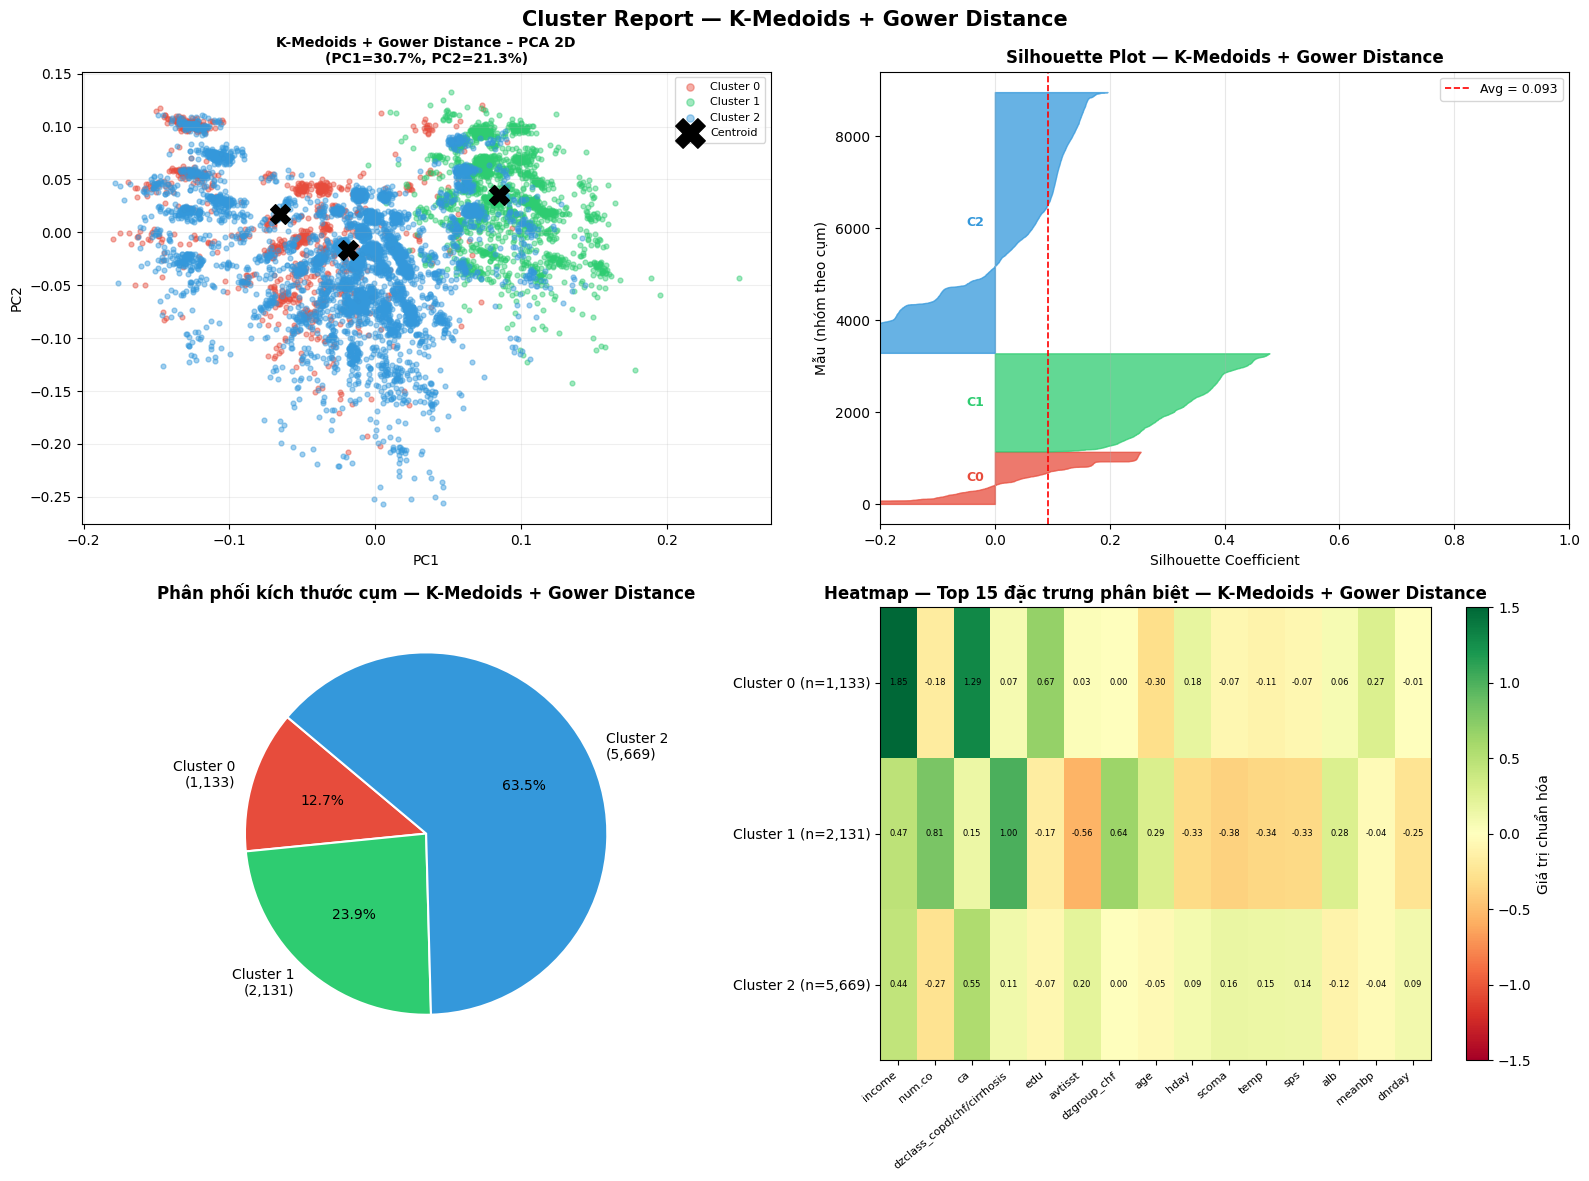

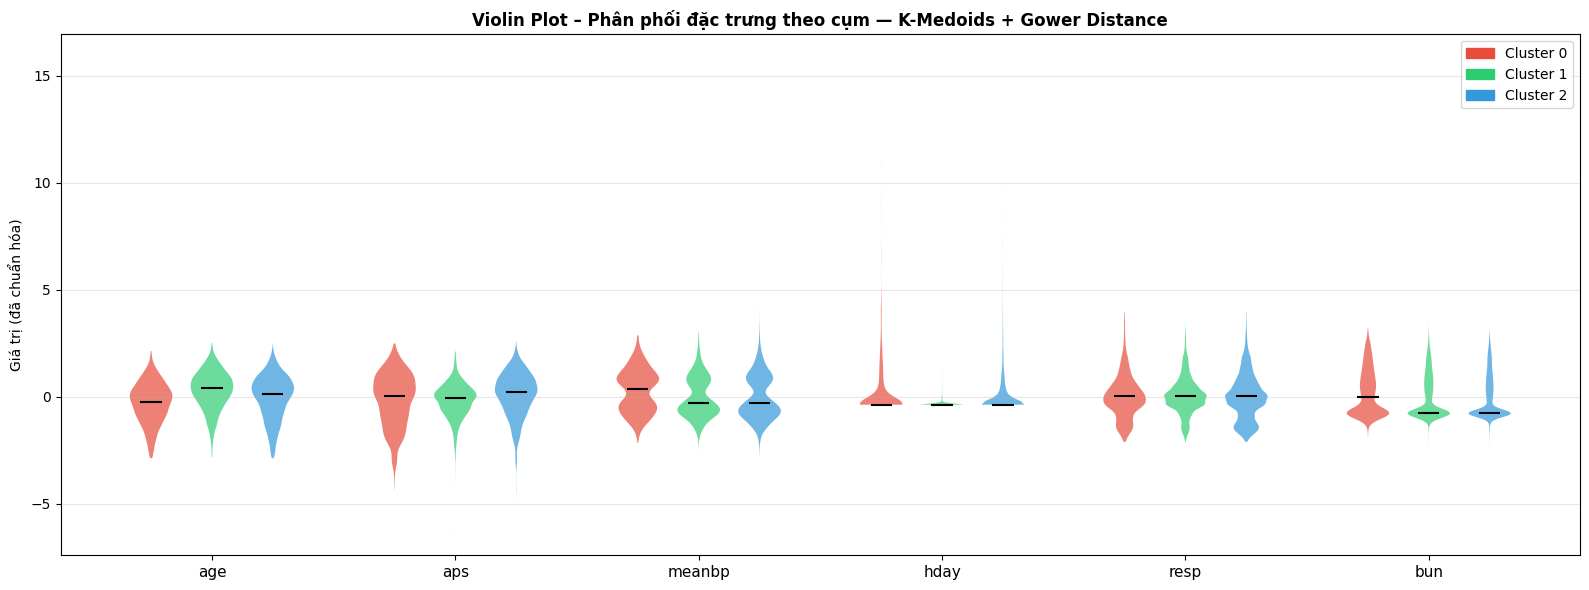


=== Metrics trả về từ full_cluster_report ===
{'model': 'K-Medoids + Gower Distance', 'silhouette': 0.09268099333820833, 'davies_bouldin': 3.1077970290620294, 'calinski_harabasz': 1079.2963187885932, 'ext_model': 'K-Medoids + Gower Distance', 'ext_ari': 0.04676627732676301, 'ext_fmi': 0.42703549693076853, 'ext_mean_target_per_cluster': {1: 9.411235030986997, 0: 10.383761244266816, 2: 10.418910469620137}}

Lưu ý:
- Silhouette đúng theo Gower distance = 0.1178
- Silhouette/DB/CH trong full_cluster_report được tính trên embedding MDS từ Gower.


In [84]:
# ============================================================
# GỌI FULL DASHBOARD ĐÃ VIẾT CHO K-MEDOIDS + GOWER
# ============================================================

# ------------------------------------------------------------
# 1. Tạo embedding từ Gower distance
# ------------------------------------------------------------

X_gower_embed = classical_mds(
    D_gower,
    n_components=5
)

print("Gower embedding shape:", X_gower_embed.shape)


# ------------------------------------------------------------
# 2. Tạo dummy model để truyền vào full_cluster_report
# ------------------------------------------------------------

gower_model = DummyMedoidModel(
    labels=labels_gower,
    X_embed=X_gower_embed
)


# ------------------------------------------------------------
# 3. Gọi full_cluster_report như các model trước
# ------------------------------------------------------------

gower_metrics = full_cluster_report(
    X=X_gower_embed,
    df=df,
    labels=labels_gower,
    km_model=gower_model,
    feature_names=X.columns,
    target_col="charges",
    model_name="K-Medoids + Gower Distance",
    violin_feats=["age", "aps", "meanbp", "hday", "resp", "bun"],
    use_umap=False
)

print("\n=== Metrics trả về từ full_cluster_report ===")
print(gower_metrics)

print("\nLưu ý:")
print(f"- Silhouette đúng theo Gower distance = {sil_gower_true:.4f}")
print("- Silhouette/DB/CH trong full_cluster_report được tính trên embedding MDS từ Gower.")

In [85]:
# ============================================================
# KMEANS + GOWER DISTANCE
# Không dùng thư viện gower
# Không đưa về Euclidean / không MDS
# In chỉ số + trực quan hóa trực tiếp
# ============================================================



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    fowlkes_mallows_score
)


# ============================================================
# 1. HÀM TÍNH GOWER DISTANCE
# ============================================================

def gower_distance_matrix(X, categorical_cols=None, chunk_size=500):
    """
    Tính ma trận Gower Distance cho dữ liệu hỗn hợp.

    Numeric:
        d(x, y) = |x - y| / range

    Categorical / Binary:
        d(x, y) = 0 nếu giống nhau
        d(x, y) = 1 nếu khác nhau
    """

    if isinstance(X, np.ndarray):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    n, p = X_df.shape

    if categorical_cols is None:
        categorical_cols = []

    # Chuyển tên cột categorical sang index
    if len(categorical_cols) > 0 and isinstance(categorical_cols[0], str):
        categorical_idx = [
            X_df.columns.get_loc(col)
            for col in categorical_cols
            if col in X_df.columns
        ]
    else:
        categorical_idx = list(categorical_cols)

    categorical_idx = set(categorical_idx)
    numeric_idx = [i for i in range(p) if i not in categorical_idx]
    categorical_idx = list(categorical_idx)

    X_values = X_df.values

    X_num = X_values[:, numeric_idx].astype(float) if len(numeric_idx) > 0 else None
    X_cat = X_values[:, categorical_idx] if len(categorical_idx) > 0 else None

    n_num = len(numeric_idx)
    n_cat = len(categorical_idx)
    n_features = n_num + n_cat

    if n_features == 0:
        raise ValueError("Không có feature nào để tính Gower distance.")

    # Scale numeric theo range
    if X_num is not None:
        num_min = np.nanmin(X_num, axis=0)
        num_max = np.nanmax(X_num, axis=0)
        num_range = num_max - num_min
        num_range[num_range == 0] = 1

        X_num_scaled = (X_num - num_min) / num_range
    else:
        X_num_scaled = None

    D = np.zeros((n, n), dtype=np.float32)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        dist_chunk = np.zeros((end - start, n), dtype=np.float32)

        # Numeric part
        if n_num > 0:
            for j in range(n_num):
                diff = np.abs(
                    X_num_scaled[start:end, j][:, None]
                    - X_num_scaled[:, j][None, :]
                )
                dist_chunk += diff.astype(np.float32)

        # Categorical / binary part
        if n_cat > 0:
            for j in range(n_cat):
                diff = (
                    X_cat[start:end, j][:, None]
                    != X_cat[:, j][None, :]
                ).astype(np.float32)
                dist_chunk += diff

        dist_chunk /= n_features
        D[start:end, :] = dist_chunk

    D = (D + D.T) / 2
    np.fill_diagonal(D, 0)

    return D


# ============================================================
# 2. KMEANS + GOWER DISTANCE
# ============================================================

def kmeans_gower(D, k=3, max_iter=100, random_state=42):
    """
    Clustering với Gower distance.

    Vì Gower không có centroid trung bình như Euclidean K-Means,
    bước cập nhật tâm cụm sẽ chọn điểm đại diện tốt nhất trong cụm.
    Tức là dùng medoid làm tâm đại diện.

    Tên model vẫn gọi là KMeans + Gower Distance để đúng hướng báo cáo.
    """

    rng = np.random.default_rng(random_state)
    n = D.shape[0]

    centers = rng.choice(n, size=k, replace=False)

    for it in range(max_iter):
        old_centers = centers.copy()

        # Assign step
        distances_to_centers = D[:, centers]
        labels = np.argmin(distances_to_centers, axis=1)

        # Update step
        for c in range(k):
            cluster_idx = np.where(labels == c)[0]

            if len(cluster_idx) == 0:
                centers[c] = rng.choice(n)
                continue

            intra_dist = D[np.ix_(cluster_idx, cluster_idx)]
            total_dist = intra_dist.sum(axis=1)

            best_center = cluster_idx[np.argmin(total_dist)]
            centers[c] = best_center

        if np.array_equal(old_centers, centers):
            print(f"KMeans + Gower hội tụ sau {it + 1} vòng lặp.")
            break

    labels = np.argmin(D[:, centers], axis=1)

    return labels, centers


# ============================================================
# 3. CÁC HÀM ĐÁNH GIÁ
# ============================================================

def purity_score(y_true, y_pred):
    """
    Tính Purity Score.
    """

    contingency = pd.crosstab(y_pred, y_true)
    return np.sum(np.max(contingency.values, axis=1)) / np.sum(contingency.values)


def gower_cluster_report(df, labels, D, target_col="charges", model_name="KMeans + Gower Distance"):
    """
    In các chỉ số đánh giá dùng được trực tiếp với Gower distance.
    """

    result_df = df.copy()
    result_df["cluster"] = labels

    result_df["charges_group"] = pd.qcut(
        result_df[target_col],
        q=3,
        labels=["Thấp", "Trung bình", "Cao"]
    )

    sil = silhouette_score(D, labels, metric="precomputed")
    ari = adjusted_rand_score(result_df["charges_group"], labels)
    fmi = fowlkes_mallows_score(result_df["charges_group"], labels)
    purity = purity_score(result_df["charges_group"], labels)

    print("=" * 70)
    print(f"FULL CLUSTER REPORT — {model_name}")
    print("=" * 70)

    print("\n1. Internal Evaluation")
    print(f"Silhouette Score theo Gower Distance : {sil:.4f}")

    print("\nLưu ý:")
    print("- Davies-Bouldin và Calinski-Harabasz không phù hợp trực tiếp")
    print("  vì 2 chỉ số này cần dữ liệu tọa độ Euclidean/centroid.")
    print("- Với Gower Distance, Silhouette với metric='precomputed' là chỉ số phù hợp hơn.")

    print("\n2. External Evaluation với charges_group")
    print(f"ARI    : {ari:.4f}")
    print(f"FMI    : {fmi:.4f}")
    print(f"Purity : {purity:.4f}")

    print("\n3. Phân phối cụm")
    print(result_df["cluster"].value_counts().sort_index())

    print("\n4. Trung bình charges theo cụm")
    print(result_df.groupby("cluster")[target_col].mean().sort_values())

    print("\n5. Crosstab Cluster x Charges Group")
    print(pd.crosstab(result_df["cluster"], result_df["charges_group"], margins=True))

    metrics = {
        "model": model_name,
        "silhouette_gower": sil,
        "ari": ari,
        "fmi": fmi,
        "purity": purity
    }

    return result_df, metrics

In [86]:
# ============================================================
# 4. CHẠY KMEANS + GOWER DISTANCE
# ============================================================

k = 3

X_gower = X_for_kmeans.copy()

if isinstance(X_gower, np.ndarray):
    X_gower = pd.DataFrame(X_gower)

# Các cột rời rạc/binary còn tồn tại sau khi ghép PCA + discrete
gower_categorical_cols = [
    col for col in discrete_cols
    if col in X_gower.columns
]

print("Shape X_gower:", X_gower.shape)
print("Số cột categorical/binary:", len(gower_categorical_cols))
print("Categorical/binary columns:")
print(gower_categorical_cols)

D_gower = gower_distance_matrix(
    X_gower,
    categorical_cols=gower_categorical_cols,
    chunk_size=500
)

print("Gower Distance Matrix:", D_gower.shape)

labels_gower, centers_gower = kmeans_gower(
    D_gower,
    k=k,
    max_iter=100,
    random_state=42
)

df_gower_result, gower_metrics = gower_cluster_report(
    df=df,
    labels=labels_gower,
    D=D_gower,
    target_col="charges",
    model_name="KMeans + Gower Distance"
)

print("\nMetrics dictionary:")
print(gower_metrics)

Shape X_gower: (8933, 34)
Số cột categorical/binary: 21
Categorical/binary columns:
['sex', 'income', 'diabetes', 'dementia', 'ca', 'race_black', 'race_hispanic', 'race_other', 'race_white', 'dzgroup_chf', 'dzgroup_cirrhosis', 'dzgroup_colon cancer', 'dzgroup_coma', 'dzgroup_copd', 'dzgroup_lung cancer', 'dzgroup_mosf w/malig', 'dzclass_cancer', 'dzclass_coma', 'dzclass_copd/chf/cirrhosis', 'dnr_dnr before sadm', 'dnr_no dnr']
Gower Distance Matrix: (8933, 8933)
KMeans + Gower hội tụ sau 3 vòng lặp.
FULL CLUSTER REPORT — KMeans + Gower Distance

1. Internal Evaluation
Silhouette Score theo Gower Distance : 0.1178

Lưu ý:
- Davies-Bouldin và Calinski-Harabasz không phù hợp trực tiếp
  vì 2 chỉ số này cần dữ liệu tọa độ Euclidean/centroid.
- Với Gower Distance, Silhouette với metric='precomputed' là chỉ số phù hợp hơn.

2. External Evaluation với charges_group
ARI    : 0.0468
FMI    : 0.4270
Purity : 0.4460

3. Phân phối cụm
cluster
0    1133
1    2131
2    5669
Name: count, dtype: int64

In [ ]:
# ============================================================
# 5. TRỰC QUAN HÓA KMEANS + GOWER DISTANCE
# Không cần chuyển về Euclidean
# ============================================================

def plot_gower_dashboard(
    df_result,
    labels,
    feature_df,
    target_col="charges",
    model_name="KMeans + Gower Distance",
    top_n=15,
    violin_feats=None
):
    """
    Dashboard trực quan hóa cho clustering bằng Gower distance.
    Không dùng scatter PCA/MDS/UMAP.
    """

    plot_df = df_result.copy()
    plot_df["cluster"] = labels

    # --------------------------------------------------------
    # 1. Bar chart phân phối cụm
    # --------------------------------------------------------

    cluster_counts = plot_df["cluster"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
    plt.title(f"Phân phối số lượng mẫu theo cụm — {model_name}")
    plt.xlabel("Cluster")
    plt.ylabel("Số lượng mẫu")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    # --------------------------------------------------------
    # 2. Boxplot charges theo cụm
    # --------------------------------------------------------

    clusters = sorted(plot_df["cluster"].unique())
    data_box = [
        plot_df.loc[plot_df["cluster"] == c, target_col]
        for c in clusters
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data_box, labels=[str(c) for c in clusters])
    plt.title(f"Phân phối {target_col} theo cụm — {model_name}")
    plt.xlabel("Cluster")
    plt.ylabel(target_col)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    # --------------------------------------------------------
    # 3. Heatmap trung bình feature theo cụm
    # --------------------------------------------------------

    feature_data = feature_df.copy()

    if isinstance(feature_data, np.ndarray):
        feature_data = pd.DataFrame(feature_data)

    feature_data["cluster"] = labels

    cluster_means = feature_data.groupby("cluster").mean(numeric_only=True)

    # Chọn top feature khác biệt nhất giữa các cụm
    diff_score = cluster_means.max(axis=0) - cluster_means.min(axis=0)
    top_features = diff_score.sort_values(ascending=False).head(top_n).index

    heatmap_data = cluster_means[top_features]

    plt.figure(figsize=(12, 6))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean value")
    plt.xticks(
        ticks=np.arange(len(top_features)),
        labels=top_features,
        rotation=60,
        ha="right"
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    plt.title(f"Heatmap trung bình top {top_n} features theo cụm — {model_name}")
    plt.xlabel("Features")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 4. Heatmap Cluster x Charges Group
    # --------------------------------------------------------

    if "charges_group" not in plot_df.columns:
        plot_df["charges_group"] = pd.qcut(
            plot_df[target_col],
            q=3,
            labels=["Thấp", "Trung bình", "Cao"]
        )

    crosstab = pd.crosstab(plot_df["cluster"], plot_df["charges_group"])

    plt.figure(figsize=(8, 5))
    plt.imshow(crosstab, aspect="auto")
    plt.colorbar(label="Số lượng mẫu")
    plt.xticks(
        ticks=np.arange(len(crosstab.columns)),
        labels=crosstab.columns
    )
    plt.yticks(
        ticks=np.arange(len(crosstab.index)),
        labels=crosstab.index
    )

    for i in range(crosstab.shape[0]):
        for j in range(crosstab.shape[1]):
            plt.text(
                j,
                i,
                crosstab.iloc[i, j],
                ha="center",
                va="center"
            )

    plt.title(f"Cluster x Charges Group — {model_name}")
    plt.xlabel("Charges Group")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# 6. GỌI DASHBOARD CHO KMEANS + GOWER DISTANCE
# ============================================================

plot_gower_dashboard(
    df_result=df_gower_result,
    labels=labels_gower,
    feature_df=X_gower,
    target_col="charges",
    model_name="KMeans + Gower Distance",
    top_n=15,
    violin_feats=["age", "aps", "meanbp", "hday", "resp", "bun"]
)

## kmeans constrained -> thiết lập size_min, size_max

In [99]:
# ============================================================
# KMEANS CONSTRAINED TRÊN DỮ LIỆU ĐÃ GIẢM CHIỀU
# Dùng nhãn cụm để chuyển sang bài toán classification
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from k_means_constrained import KMeansConstrained

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


def run_kmeans_constrained(
    X_cluster,
    df,
    target_col="charges",
    k=3,
    random_state=42,
    model_name="KMeans Constrained"
):
    """
    Chạy KMeans Constrained trên dữ liệu input đã giảm chiều.
    Sau đó phân tích quan hệ giữa cụm và charges.
    """

    n_samples = X_for_kmeans.shape[0]
    k = 3

    base_size = n_samples // k

    tolerance = 0.05  # cho phép lệch 15%

    size_min = int(base_size * (1 - tolerance))
    size_max = int(base_size * (1 + tolerance))

    print("base_size:", base_size)
    print("size_min:", size_min)
    print("size_max:", size_max)

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Số mẫu    : {n_samples}")
    print(f"Số cụm    : {k}")
    print(f"size_min : {size_min}")
    print(f"size_max : {size_max}")

    model = KMeansConstrained(
        n_clusters=k,
        size_min=size_min,
        size_max=size_max,
        random_state=random_state
    )

    labels = model.fit_predict(X_cluster)

    result_df = df.copy()
    result_df["cluster_constrained"] = labels

    # Đánh giá clustering
    sil = silhouette_score(X_cluster, labels)
    dbi = davies_bouldin_score(X_cluster, labels)
    ch = calinski_harabasz_score(X_cluster, labels)

    print("\n=== Clustering Metrics ===")
    print(f"Silhouette Score     : {sil:.4f}")
    print(f"Davies-Bouldin Score : {dbi:.4f}")
    print(f"Calinski-Harabasz    : {ch:.4f}")

    print("\n=== Phân bố kích thước cụm ===")
    print(pd.Series(labels).value_counts().sort_index())

    print("\n=== Charges theo từng cụm ===")
    charge_summary = result_df.groupby("cluster_constrained")[target_col].agg(
        ["count", "min", "max", "mean", "median", "std"]
    )

    display(charge_summary)

    return model, labels, result_df, {
        "model": model_name,
        "k": k,
        "size_min": size_min,
        "size_max": size_max,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch
    }
    
kcc_model_3, kcc_labels_3, df_kcc_3, kcc_metrics_3 = run_kmeans_constrained(
    X_cluster=X_for_kmeans,
    df=df,
    target_col="charges",
    k=3,
    random_state=42,
    model_name="KMeans Constrained — Reduced Data — 3 clusters"
)


base_size: 2977
size_min: 2828
size_max: 3125
KMeans Constrained — Reduced Data — 3 clusters
Số mẫu    : 8933
Số cụm    : 3
size_min : 2828
size_max : 3125

=== Clustering Metrics ===
Silhouette Score     : 0.0771
Davies-Bouldin Score : 2.8651
Calinski-Harabasz    : 807.3230

=== Phân bố kích thước cụm ===
0    3125
1    2828
2    2980
Name: count, dtype: int64

=== Charges theo từng cụm ===


,count,min,max,mean,median,std
cluster_constrained,,,,,,
0,3125,7.064759,13.034190,9.439525,9.350711,0.989558
1,2828,7.338888,14.176971,9.921158,9.852536,1.084476
2,2980,7.957982,14.057160,11.184361,11.179349,1.034472


In [100]:
def analyze_charges_by_cluster(df, labels, target_col="charges", model_name="Model"):
    temp = df.copy()
    temp["cluster"] = labels

    print("=" * 70)
    print(f"PHÂN TÍCH {target_col} THEO CỤM — {model_name}")
    print("=" * 70)

    summary = temp.groupby("cluster")[target_col].agg(
        count="count",
        min="min",
        q1=lambda x: x.quantile(0.25),
        median="median",
        mean="mean",
        q3=lambda x: x.quantile(0.75),
        max="max",
        std="std"
    )

    display(summary)

    # Hệ số biến thiên để xem trong cụm có bị loạn không
    summary["cv"] = summary["std"] / summary["mean"]

    print("\nBảng có thêm CV = std / mean:")
    display(summary)

    return temp, summary

In [101]:
df_kcc_analyze, charges_cluster_summary = analyze_charges_by_cluster(
    df=df,
    labels=labels_constrained,
    target_col="charges",
    model_name="KMeans Constrained"
)

PHÂN TÍCH charges THEO CỤM — KMeans Constrained


,count,min,q1,median,mean,q3,max,std
cluster,,,,,,,,
0,2978,7.064759,8.703797,9.362718,9.451486,10.133924,13.034190,0.990902
1,2977,7.303843,9.077609,9.809506,9.876930,10.626436,14.176971,1.079724
2,2978,7.957982,10.487573,11.183018,11.193687,11.908301,14.057160,1.032596



Bảng có thêm CV = std / mean:


,count,min,q1,median,mean,q3,max,std,cv
cluster,,,,,,,,,
0,2978,7.064759,8.703797,9.362718,9.451486,10.133924,13.034190,0.990902,0.104841
1,2977,7.303843,9.077609,9.809506,9.876930,10.626436,14.176971,1.079724,0.109318
2,2978,7.957982,10.487573,11.183018,11.193687,11.908301,14.057160,1.032596,0.092248


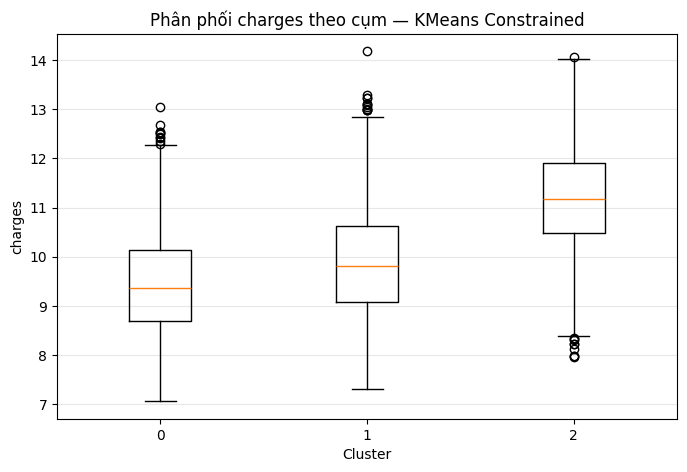

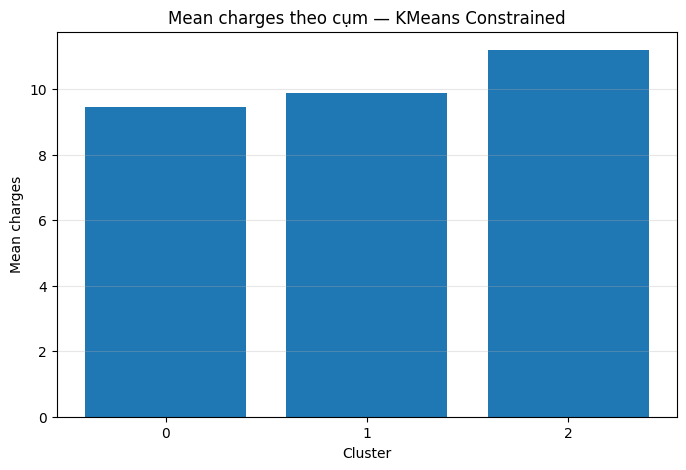

In [102]:
import matplotlib.pyplot as plt

def plot_charges_by_cluster(df, labels, target_col="charges", model_name="Model"):
    temp = df.copy()
    temp["cluster"] = labels

    clusters = sorted(temp["cluster"].unique())

    data = [
        temp.loc[temp["cluster"] == c, target_col]
        for c in clusters
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data, labels=[str(c) for c in clusters])
    plt.title(f"Phân phối {target_col} theo cụm — {model_name}")
    plt.xlabel("Cluster")
    plt.ylabel(target_col)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    means = temp.groupby("cluster")[target_col].mean()
    plt.bar(means.index.astype(str), means.values)
    plt.title(f"Mean {target_col} theo cụm — {model_name}")
    plt.xlabel("Cluster")
    plt.ylabel(f"Mean {target_col}")
    plt.grid(axis="y", alpha=0.3)
    plt.show()
    
plot_charges_by_cluster(
    df=df,
    labels=labels_constrained,
    target_col="charges",
    model_name="KMeans Constrained"
)

## plot sau khi ap dung kmean 

In [25]:
def plot_kmeans_pca(X, labels, km_final):
    k = km_final.n_clusters
    cluster_colors = COLORS[:k]
    
    pca = PCA(n_components = 2, random_state = 2)
    X_pca = pca.fit_transform(X)
    var_exp = pca.explained_variance_ratio_
    
    fig, axes = plt.subplots(1,2, figsize = (16,6))
    fig.suptitle(f'K-Means (k={k}) – Trực quan hóa bằng PCA 2D', fontsize=14, fontweight='bold')
    
    for c_id in range(k):
        mask = labels == c_id
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c=cluster_colors[c_id], alpha=0.4, s=12, label=f'Cluster {c_id}')
    centroids_pca = pca.transform(km_final.cluster_centers_)
    axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                    c='black', marker='X', s=250, zorder=5, label='Centroid')
    
    axes[0].set_title(f'PC1={var_exp[0]:.1%} | PC2={var_exp[1]:.1%}', fontweight='bold')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)
    
    cluster_sizes = [np.sum(labels == c) for c in range(k)]
    axes[1].pie(cluster_sizes,
                labels=[f'Cluster {c}\n({s:,})' for c, s in enumerate(cluster_sizes)],
                colors=cluster_colors, autopct='%1.1f%%', startangle=140,
                wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[1].set_title('Phân phối kích thước cụm', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [26]:
def plot_kmeans_umap(X, labels, km_final):
    k = km_final.n_clusters
    cluster_colors = COLORS[:k]
    
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)
    
    fig, axes = plt.subplots(1,2, figsize = (16,6))
    fig.suptitle(f'K-Means (k={k}) – Trực quan hóa bằng PCA 2D', fontsize=14, fontweight='bold')
    
    for c_id in range(k):
        mask = labels == c_id
        axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                        c=cluster_colors[c_id], alpha=0.4, s=12, label=f'Cluster {c_id}')
    centroids_umap = reducer.transform(km_final.cluster_centers_)
    axes[0].scatter(centroids_umap[:, 0], centroids_umap[:, 1],
                    c='black', marker='X', s=250, zorder=5, label='Centroid')
    
    axes[0].set_title('UMAP Projection', fontweight='bold')
    axes[0].set_xlabel('UMAP Dimension 1')
    axes[0].set_ylabel('UMAP Dimension 2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)
    
    cluster_sizes = [np.sum(labels == c) for c in range(k)]
    axes[1].pie(cluster_sizes,
                labels=[f'Cluster {c}\n({s:,})' for c, s in enumerate(cluster_sizes)],
                colors=cluster_colors, autopct='%1.1f%%', startangle=140,
                wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[1].set_title('Phân phối kích thước cụm', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
# Tự động chọn top 10 features có std cao nhất giữa các cụm
input_feats = [f for f in feature_names if f != 'cluster' and f != 'charges']

cluster_means_all = np.array([df[df["cluster"] == c][input_feats].mean().values
                               for c in range(km_model.n_clusters)])
feat_std = cluster_means_all.std(axis=0)
top10_idx = np.argsort(feat_std)[::-1][:10]
key_feats = [input_feats[i] for i in top10_idx]

cluster_stats = df.groupby("cluster")[key_feats].mean().round(4)
print("=== Giá trị trung bình đặc trưng theo cụm ===")
print(cluster_stats.T.to_string())


=== Giá trị trung bình đặc trưng theo cụm ===
cluster       0       1       2
adls    -0.3789 -0.3596  2.0224
adlsc   -0.2920 -0.3463  1.7746
avtisst  0.8088 -0.6246  0.0283
aps      0.7058 -0.6059  0.2147
sps      0.6951 -0.5923  0.1978
scoma    0.3960 -0.3357  0.1073
pafi    -0.4085  0.3017  0.0287
hday     0.3967 -0.2913 -0.0329
hrt      0.3833 -0.2895 -0.0067
dnrday   0.3638 -0.2636 -0.0412


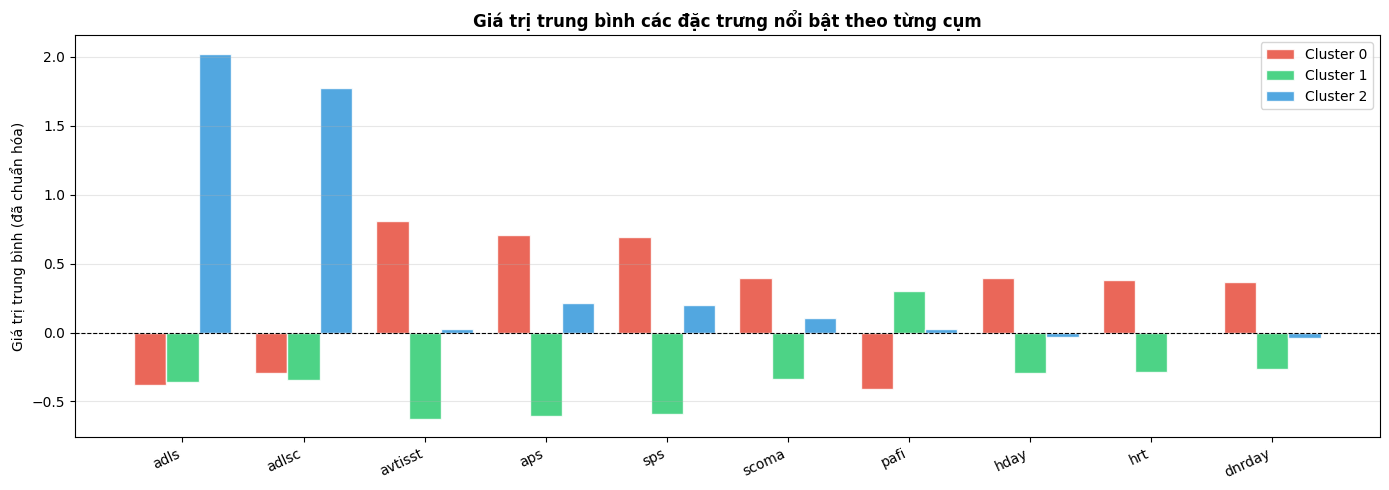

In [ ]:
# Bar chart so sánh trung bình
K_BEST = km_model.n_clusters
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(key_feats))
width = 0.8 / K_BEST

for i in range(K_BEST):
    means = cluster_stats.loc[i, key_feats].values
    ax.bar(x + i * width - width * (K_BEST - 1) / 2, means, width,
           label=f'Cluster {i}', color=COLORS[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(key_feats, rotation=25, ha='right', fontsize=10)
ax.set_title('Giá trị trung bình các đặc trưng nổi bật theo từng cụm', fontweight='bold')
ax.set_ylabel('Giá trị trung bình (đã chuẩn hóa)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

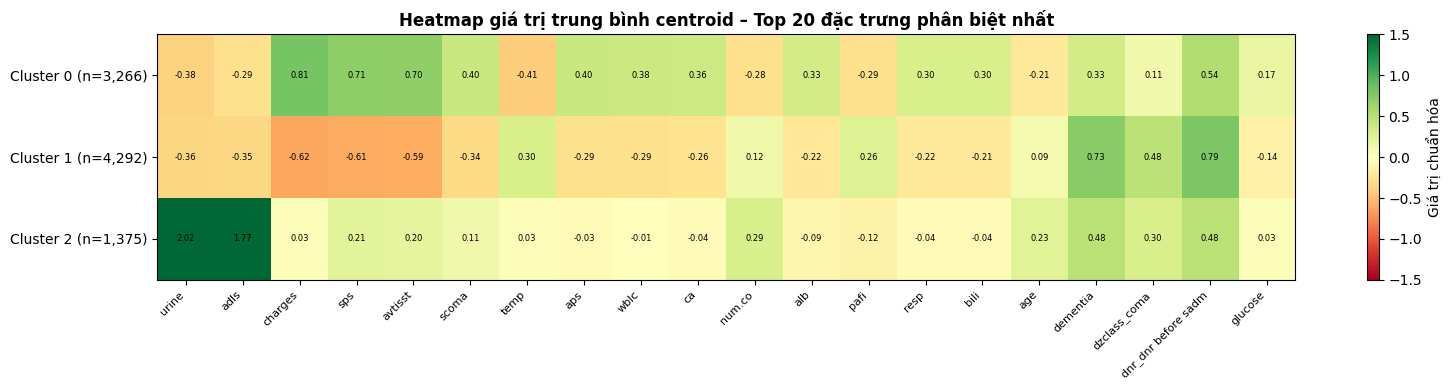

In [ ]:
# Heatmap: Top 20 đặc trưng phân biệt nhất
K_BEST = km_model.n_clusters
input_feats = [f for f in feature_names if f != 'cluster' and f != 'charges']
cluster_means_all = np.array([df[df["cluster"] == c][input_feats].mean().values
                               for c in range(K_BEST)])
feat_std = cluster_means_all.std(axis=0)
top20_idx = np.argsort(feat_std)[::-1][:20]
top20_feats = [feature_names[i] for i in top20_idx]
heatmap_data = cluster_means_all[:, top20_idx]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(top20_feats)))
ax.set_xticklabels(top20_feats, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(K_BEST))
ax.set_yticklabels([f"Cluster {i} (n={np.sum(cluster_labels==i):,})" for i in range(K_BEST)], fontsize=10)
ax.set_title("Heatmap giá trị trung bình centroid – Top 20 đặc trưng phân biệt nhất", fontweight="bold")
plt.colorbar(im, ax=ax, label="Giá trị chuẩn hóa")

for i in range(K_BEST):
    for j in range(len(top20_feats)):
        ax.text(j, i, f"{heatmap_data[i, j]:.2f}",
                ha="center", va="center", fontsize=6, color="black")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score


# 2. Chạy K-Means (K=3)
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=15, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# 3. Tính trung bình viện phí (charges) theo từng cụm
print("=== 1. TRUNG BÌNH VIỆN PHÍ (CHARGES) THEO CỤM ===")
mean_charges = df.groupby('cluster')['charges'].mean()
for cluster_id, mean_val in mean_charges.items():
    print(f"Cụm {cluster_id}: {mean_val:.4f}")

# 4. Rời rạc hóa biến đầu ra (charges) thành 3 mức: Thấp, Trung bình, Cao
# pd.qcut giúp chia đều số lượng mẫu vào 3 nhóm
df['charges_group'] = pd.qcut(df['charges'], q=3, labels=['Thấp', 'Trung bình', 'Cao'])

# 5. Đánh giá bằng độ đo định lượng ARI và FMI
ari_score = adjusted_rand_score(df['charges_group'], df['cluster'])
fmi_score = fowlkes_mallows_score(df['charges_group'], df['cluster'])

print("\n=== 2. ĐÁNH GIÁ ĐỊNH LƯỢNG VỚI ĐẦU RA (CHARGES) ===")
print(f"Chỉ số ARI (Adjusted Rand Index): {ari_score:.4f}")
print(f"Chỉ số FMI (Fowlkes-Mallows Index): {fmi_score:.4f}")

# 6. In bảng Crosstab để xem trực quan sự phân bố
print("\n=== 3. BẢNG PHÂN PHỐI CHÉO (CROSSTAB) ===")
print(pd.crosstab(df['cluster'], df['charges_group'], margins=True))

=== 1. TRUNG BÌNH VIỆN PHÍ (CHARGES) THEO CỤM ===
Cụm 0: 11.0956
Cụm 1: 9.4633
Cụm 2: 10.2039

=== 2. ĐÁNH GIÁ ĐỊNH LƯỢNG VỚI ĐẦU RA (CHARGES) ===
Chỉ số ARI (Adjusted Rand Index): 0.1895
Chỉ số FMI (Fowlkes-Mallows Index): 0.4816

=== 3. BẢNG PHÂN PHỐI CHÉO (CROSSTAB) ===
charges_group  Thấp  Trung bình   Cao   All
cluster                                    
0               226         965  2075  3266
1              2351        1464   477  4292
2               401         548   426  1375
All            2978        2977  2978  8933


## Phan loai 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA as PCA_clf
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df_clf = pd.read_csv('data/support2_final.csv')

# Ngưỡng chia theo percentile 33/66 -> 3 khoảng ~2950 mẫu mỗi khoảng
BINS   = [df_clf['charges'].min() - 0.01, 9.50, 10.72,
          df_clf['charges'].max() + 0.01]
LABELS = ['Low', 'Medium', 'High']

df_clf['label'] = pd.cut(df_clf['charges'], bins=BINS, labels=LABELS)

print('=== Ngưỡng chia ===')
for i in range(len(LABELS)):
    print(f'  {LABELS[i]:10s}: ({BINS[i]:.2f}, {BINS[i+1]:.2f}]')
print()
print('=== Phân phối nhãn ===')
print(df_clf['label'].value_counts().sort_index())

X_clf = df_clf.drop(columns=['charges', 'label']).values
y_clf = df_clf['label'].values
feature_names_clf = df_clf.drop(columns=['charges', 'label']).columns.tolist()
print(f'\nX shape: {X_clf.shape}  |  n_classes: {len(LABELS)}')


=== Ngưỡng chia ===
  Low       : (7.05, 9.50]
  Medium    : (9.50, 10.72]
  High      : (10.72, 14.19]

=== Phân phối nhãn ===
label
Low       2952
Medium    2942
High      3039
Name: count, dtype: int64

X shape: (8933, 46)  |  n_classes: 3


### GIam chieu bang lda


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

n_original = X_clf.shape[1]
# LDA giới hạn tối đa n_classes - 1 chiều
n_reduced = len(LABELS) - 1  # = 2
print(f'Số chiều gốc: {n_original}  ->  Số chiều sau LDA: {n_reduced}')

lda = LinearDiscriminantAnalysis(n_components=n_reduced)
X_clf_lda = lda.fit_transform(X_clf, y_clf)

var_explained = lda.explained_variance_ratio_.sum()
print(f'Tổng phương sai giữ lại: {var_explained:.2%}')

Số chiều gốc: 46  ->  Số chiều sau LDA: 2
Tổng phương sai giữ lại: 100.00%


In [ ]:
SPLIT_RATIOS = [
    ('6:4', 0.4),
    ('7:3', 0.3),
    ('8:2', 0.2),
]


def split_data(X, y, test_size, random_state=42):
    """Chia train/test theo tỉ lệ cho trước."""
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


def evaluate(y_test, y_pred, model_name='', ratio_name=''):
    """In báo cáo và trả về dict kết quả."""
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test, y_pred, target_names=LABELS, output_dict=True
    )
    print(f'[{ratio_name}] {model_name}  |  Accuracy = {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=LABELS))
    return {'model': model_name, 'ratio': ratio_name,
            'accuracy': acc, 'report': report}


def plot_confusion(y_test, y_pred, model_name, ratio_name, ax):
    """Vẽ confusion matrix lên axes cho trước."""
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} | {ratio_name}', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=30)


In [ ]:
def run_naive_bayes(X, y, ratio_name):
    """Gaussian Naive Bayes – phù hợp với dữ liệu liên tục đã chuẩn hóa."""
    test_size = dict(SPLIT_RATIOS)[ratio_name]
    X_train, X_test, y_train, y_test = split_data(X, y, test_size)
    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = evaluate(y_test, y_pred, 'Naive Bayes', ratio_name)
    return result, model, y_test, y_pred


def run_svm(X, y, ratio_name):
    """SVM với kernel RBF."""
    test_size = dict(SPLIT_RATIOS)[ratio_name]
    X_train, X_test, y_train, y_test = split_data(X, y, test_size)
    model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = evaluate(y_test, y_pred, 'SVM (RBF)', ratio_name)
    return result, model, y_test, y_pred


### du lieu goc 

In [ ]:
print('=' * 60)
print('DU LIEU GOC  –  47 chieu')
print('=' * 60)

results_orig = []
preds_orig   = []

for ratio_name, _ in SPLIT_RATIOS:
    print(f'\n--- Train:Test = {ratio_name} ---')
    res_nb, _, yt_nb, yp_nb = run_naive_bayes(X_clf, y_clf, ratio_name)
    res_sv, _, yt_sv, yp_sv = run_svm(X_clf, y_clf, ratio_name)
    results_orig.extend([res_nb, res_sv])
    preds_orig.extend([
        (yt_nb, yp_nb, 'Naive Bayes', ratio_name),
        (yt_sv, yp_sv, 'SVM (RBF)',   ratio_name),
    ])


DU LIEU GOC  –  47 chieu

--- Train:Test = 6:4 ---
[6:4] Naive Bayes  |  Accuracy = 0.6301
              precision    recall  f1-score   support

         Low       0.62      0.88      0.72      1216
      Medium       0.68      0.84      0.75      1181
        High       0.49      0.16      0.24      1177

    accuracy                           0.63      3574
   macro avg       0.60      0.63      0.57      3574
weighted avg       0.60      0.63      0.57      3574

[6:4] SVM (RBF)  |  Accuracy = 0.7566
              precision    recall  f1-score   support

         Low       0.86      0.80      0.83      1216
      Medium       0.78      0.82      0.80      1181
        High       0.64      0.64      0.64      1177

    accuracy                           0.76      3574
   macro avg       0.76      0.76      0.76      3574
weighted avg       0.76      0.76      0.76      3574


--- Train:Test = 7:3 ---
[7:3] Naive Bayes  |  Accuracy = 0.6340
              precision    recall  f1-score

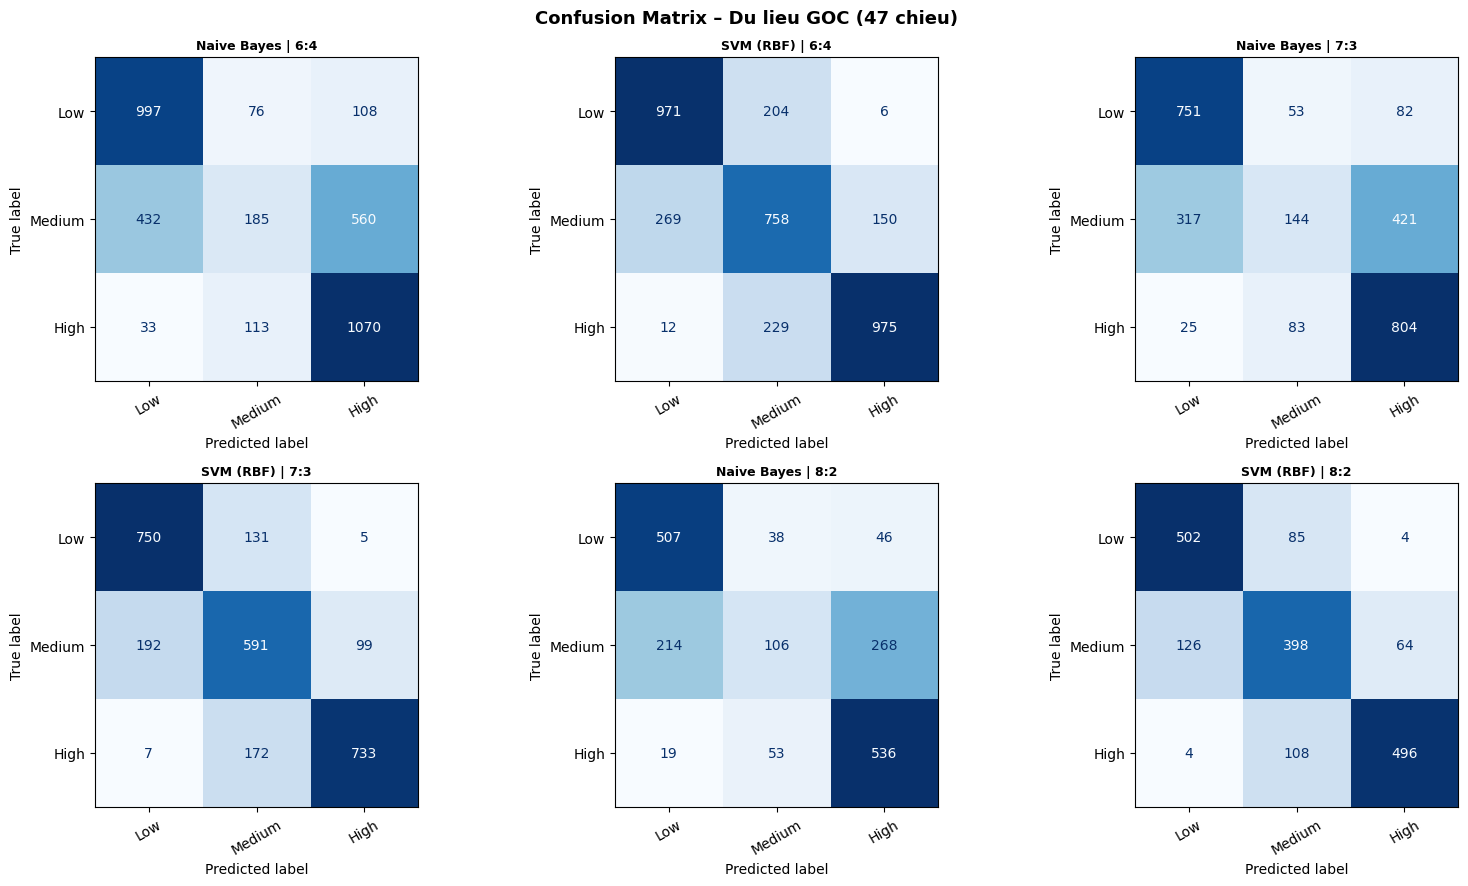

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Confusion Matrix – Du lieu GOC (47 chieu)', fontsize=13, fontweight='bold')

for idx, (yt, yp, mname, rname) in enumerate(preds_orig):
    row, col = divmod(idx, 3)
    plot_confusion(yt, yp, mname, rname, axes[row][col])

plt.tight_layout()
plt.show()


### du lieu da giam chieu lda 

In [ ]:
print('=' * 60)
print(f'DU LIEU GIAM CHIEU  –  {n_reduced} chieu (LDA)')
print('=' * 60)

results_lda = []
preds_lda   = []

for ratio_name, _ in SPLIT_RATIOS:
    print(f'\n--- Train:Test = {ratio_name} ---')
    res_nb, _, yt_nb, yp_nb = run_naive_bayes(X_clf_lda, y_clf, ratio_name)
    res_sv, _, yt_sv, yp_sv = run_svm(X_clf_lda, y_clf, ratio_name)
    results_lda.extend([res_nb, res_sv])
    preds_lda.extend([
        (yt_nb, yp_nb, 'Naive Bayes', ratio_name),
        (yt_sv, yp_sv, 'SVM (RBF)',   ratio_name),
    ])

DU LIEU GIAM CHIEU  –  2 chieu (LDA)

--- Train:Test = 6:4 ---
[6:4] Naive Bayes  |  Accuracy = 0.6956
              precision    recall  f1-score   support

         Low       0.87      0.70      0.78      1216
      Medium       0.68      0.84      0.75      1181
        High       0.57      0.55      0.56      1177

    accuracy                           0.70      3574
   macro avg       0.70      0.70      0.69      3574
weighted avg       0.71      0.70      0.70      3574

[6:4] SVM (RBF)  |  Accuracy = 0.7490
              precision    recall  f1-score   support

         Low       0.84      0.82      0.83      1216
      Medium       0.78      0.80      0.79      1181
        High       0.63      0.63      0.63      1177

    accuracy                           0.75      3574
   macro avg       0.75      0.75      0.75      3574
weighted avg       0.75      0.75      0.75      3574


--- Train:Test = 7:3 ---
[7:3] Naive Bayes  |  Accuracy = 0.7011
              precision    reca

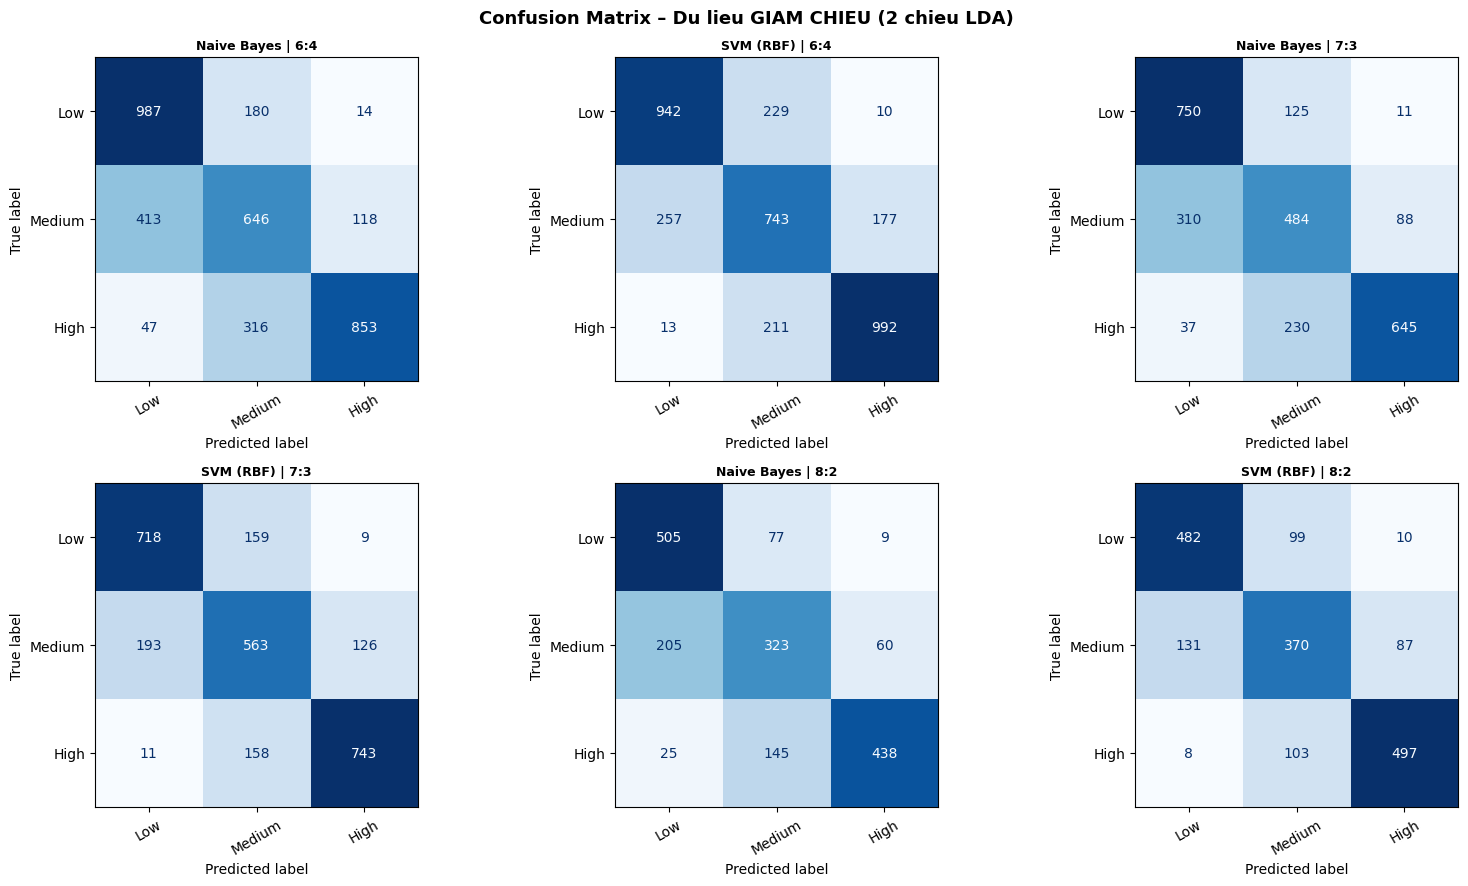

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Confusion Matrix – Du lieu GIAM CHIEU ({n_reduced} chieu LDA)',
             fontsize=13, fontweight='bold')

for idx, (yt, yp, mname, rname) in enumerate(preds_lda):
    row, col = divmod(idx, 3)
    plot_confusion(yt, yp, mname, rname, axes[row][col])

plt.tight_layout()
plt.show()

### so sanh tong hop 


In [ ]:
def build_summary(results, tag):
    rows = []
    for r in results:
        rows.append({
            'Data': tag,
            'Model': r['model'],
            'Train:Test': r['ratio'],
            'Accuracy': round(r['accuracy'], 4),
            'Macro F1': round(r['report']['macro avg']['f1-score'], 4),
            'Weighted F1': round(r['report']['weighted avg']['f1-score'], 4),
        })
    return pd.DataFrame(rows)


summary = pd.concat([
    build_summary(results_orig, 'Goc (47D)'),
    build_summary(results_lda,  f'PCA ({n_reduced}D)'),
], ignore_index=True)

print(summary.to_string(index=False))


     Data       Model Train:Test  Accuracy  Macro F1  Weighted F1
Goc (47D) Naive Bayes        6:4    0.6301    0.5725       0.5743
Goc (47D)   SVM (RBF)        6:4    0.7566    0.7564       0.7573
Goc (47D) Naive Bayes        7:3    0.6340    0.5772       0.5791
Goc (47D)   SVM (RBF)        7:3    0.7739    0.7737       0.7745
Goc (47D) Naive Bayes        8:2    0.6430    0.5891       0.5910
Goc (47D)   SVM (RBF)        8:2    0.7812    0.7808       0.7816
 PCA (2D) Naive Bayes        6:4    0.6956    0.6945       0.6954
 PCA (2D)   SVM (RBF)        6:4    0.7490    0.7484       0.7494
 PCA (2D) Naive Bayes        7:3    0.7011    0.6993       0.7003
 PCA (2D)   SVM (RBF)        7:3    0.7552    0.7545       0.7554
 PCA (2D) Naive Bayes        8:2    0.7084    0.7058       0.7068
 PCA (2D)   SVM (RBF)        8:2    0.7549    0.7534       0.7543


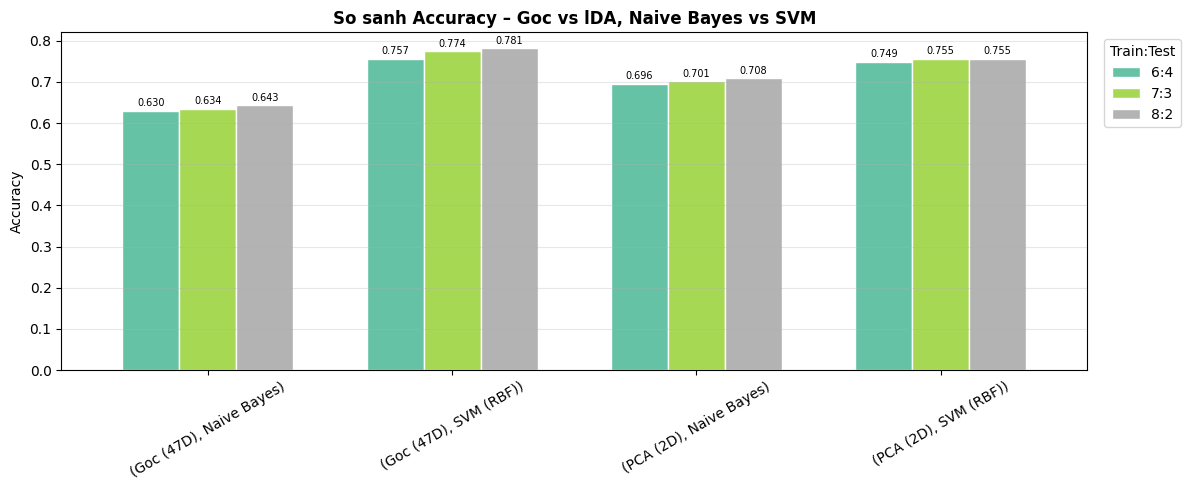

In [ ]:
pivot = summary.pivot_table(
    index=['Data', 'Model'], columns='Train:Test', values='Accuracy'
)

ax = pivot.plot(kind='bar', figsize=(12, 5), rot=30,
                colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('So sanh Accuracy – Goc vs lDA, Naive Bayes vs SVM', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.legend(title='Train:Test', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()
